In [3]:
import jax
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt
import importlib

from dshape import constructive
from dshape import core
from dshape import geometry
from dshape import mutation
from dshape import plotting
from dshape import set_ops

importlib.reload(constructive)
importlib.reload(core)
importlib.reload(geometry)
importlib.reload(mutation)
importlib.reload(plotting)
importlib.reload(set_ops)

<module 'dshape.set_ops' from '/home/seekjim20/Python/dshape/src/dshape/set_ops.py'>

# Geometry

### Polygon with holes

p4.area = Array(8., dtype=float32)


<Axes: >

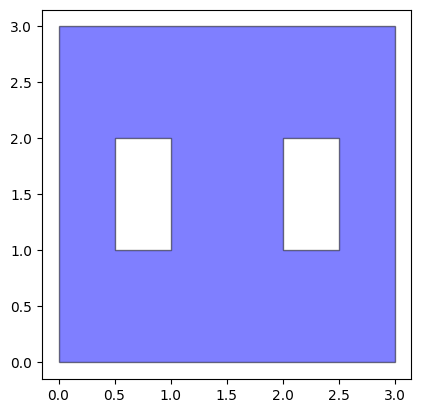

In [149]:
p1 = geometry.Rectangle(0, 0, 3, 3)
p2 = geometry.Rectangle(0.5, 1, 0.5, 1)
p3 = geometry.Rectangle(2.0, 1, 0.5, 1)

p4 = p1 - p2 - p3
print(f"{p4.area = }")
p4.plot()

### MultiPolygon

<Axes: >

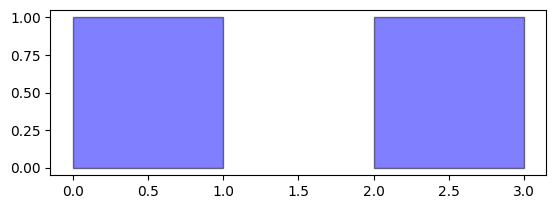

In [150]:
p1 = geometry.Rectangle(0, 0, 3, 1)
p2 = geometry.Rectangle(1, -1, 1, 3)
p3 = p1 - p2

fig, ax = plt.subplots()
p3.plot(ax=ax)

### Convex Hull

<Axes: >

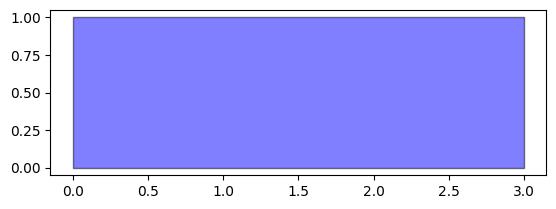

In [151]:
p4 = p3.convex_hull
p4.plot()

# Set operations

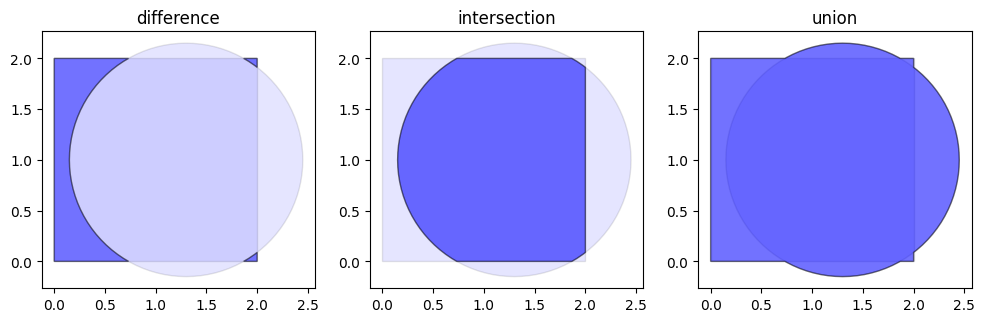

In [141]:
p1 = geometry.Rectangle(0.0, 0.0, 2.0, 2.0)
p2 = geometry.Circle(1.3, 1.0, 1.15, num_edges=100)

diff_poly = set_ops.difference(p1, p2)
intersection_poly = set_ops.intersection(p1, p2)
union_poly = set_ops.union([p1, p2])

_, ax = plt.subplots(figsize=(12, 4), ncols=3)

for i in range(3):
    ax[i].set_aspect('equal')
    p1.plot(ax[i], alpha=0.1)
    p2.plot(ax[i], alpha=0.1)

diff_poly.plot(ax[0], color='blue')
ax[0].set_title('difference')
intersection_poly.plot(ax[1], color='blue')
ax[1].set_title('intersection')
union_poly.plot(ax[2], color='blue')
ax[2].set_title('union')

plt.show()

In [142]:
p3 = constructive.convex_hull(p2)

NameError: name 'constructive' is not defined

# Mutation

### Dilation

Text(0.5, 1.0, 'Dilation')

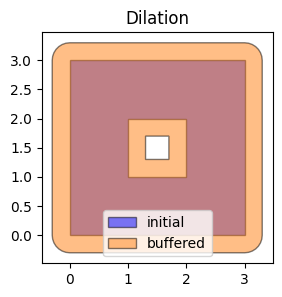

In [31]:
p1 = geometry.Rectangle(0, 0, 3, 3)
p2 = geometry.Rectangle(1, 1, 1, 1)
p3 = set_ops.difference(p1, p2)
p4 = mutation.buffer(p3, 0.3)

fig, ax = plt.subplots(figsize=(3, 3))
p3.plot(ax=ax, label='initial')
p4.plot(ax=ax, color='tab:orange', label='buffered')
ax.legend()
ax.set_title('Dilation')

### Rotation

In [123]:
p1 = geometry.Rectangle(0, 0, 3, 3)
p2 = geometry.Rectangle(1, 1, 1, 1)
p3 = set_ops.difference(p1, p2)
p4 = mutation.buffer(p3, 0.3)
p5 = mutation.rotate(p4, jnp.pi / 4, center=jnp.array([2.0, 1.5]))
plotting.plot_polygons([p1, p2, p3, p5])

## Scale

In [131]:
p1 = geometry.Rectangle(0, 0, 3, 3)
p2 = geometry.Rectangle(1, 1, 1, 1)
p3 = set_ops.difference(p1, p2)
p4 = mutation.buffer(p3, 0.3)
p5 = mutation.scale(p4, 1.5, origin=(1.5, 1.5))
plotting.plot_polygons([p1, p2, p3, p5])

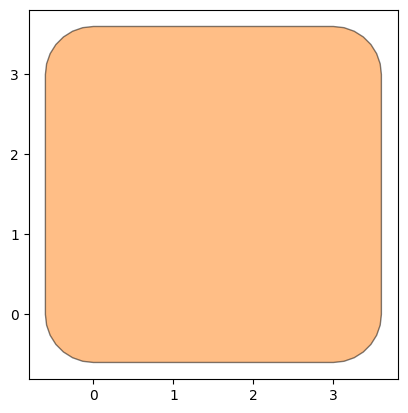

In [88]:
p1 = geometry.Rectangle(0, 0, 3, 3)
p2 = geometry.Rectangle(1, 1, 1, 1)
p3 = set_ops.difference(p1, p2)
p4 = mutation.buffer(p3, 0.6)

fig, ax = plt.subplots()
p4.plot(ax=ax, color='tab:orange');

### Erosion

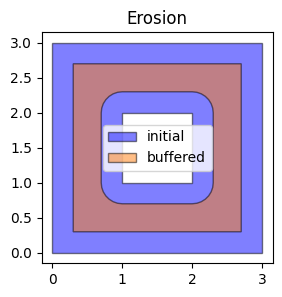

In [32]:
p1 = geometry.Rectangle(0, 0, 3, 3)
p2 = geometry.Rectangle(1, 1, 1, 1)
p3 = set_ops.difference(p1, p2)
p4 = mutation.buffer(p3, -0.3)

fig, ax = plt.subplots(figsize=(3, 3))
p3.plot(ax=ax, label='initial')
p4.plot(ax=ax, color='tab:orange', label='buffered')
ax.legend()
ax.set_title('Erosion');

### L shape

0.5795775
False


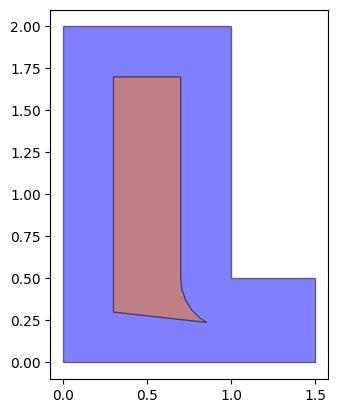

In [92]:
vertices = jnp.array(
    [[0.0, 0.0], [1.5, 0.0], [1.5, 0.5], [1.0, 0.5], [1.0, 2.0], [0.0, 2.0]],
    dtype=jnp.float32,
)
p1 = geometry.Polygon(vertices=vertices)
p2 = mutation.buffer(p1, -0.3)

fig, ax = plt.subplots()
p1.plot(ax=ax)
p2.plot(ax=ax, color='tab:orange')
print(p2.area)
print(p2.self_intersect)

# Plotting using plotly

In [95]:
p1 = geometry.Circle(0, 0, 1.15, num_edges=100)
p2 = mutation.buffer(p1, -1.0)
print(f'{p2.area = }')
plotting.plot_polygons([p1, p2])

p2.area = Array(0.0701751, dtype=float32)


# Staircase

p1.area = Array(0.5, dtype=float32)
p2.area = Array(1.306474, dtype=float32)


<Axes: >

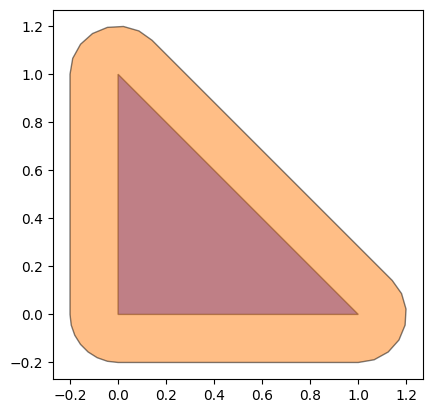

In [96]:
p1 = geometry.Polygon(
    vertices=jnp.array(
        [
            [0.0, 0.0],
            [1.0, 0.0],
            [0.0, 1.0],
        ]
    )
)
p2 = mutation.buffer(p1, 0.2)
print(f"{p1.area = }")
print(f"{p2.area = }")

fig, ax = plt.subplots()
p1.plot(ax=ax)
p2.plot(ax=ax, color='tab:orange')

# Multiple staircases

p5.area = Array(1.0218873, dtype=float32)


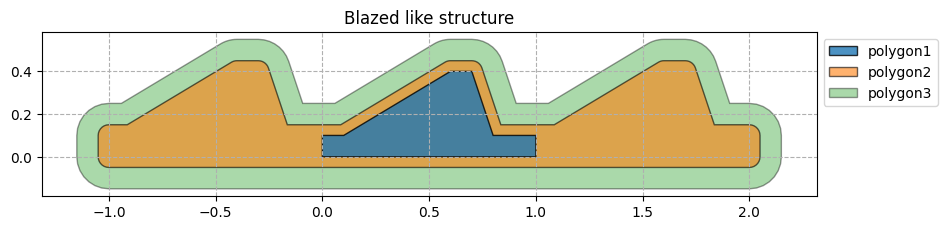

In [29]:
p1 = geometry.Polygon(
    vertices=jnp.array(
        [
            [0.0, 0.0],
            [1.0, 0.0],
            [1.0, 0.1],
            [0.8, 0.1],
            [0.7, 0.4],
            [0.6, 0.4],
            [0.1, 0.1],
            [0, 0.1],
        ]
    )
)
p2 = mutation.buffer(p1, 0.05)
p3 = mutation.offset(p2, 1.0, 0.0)
p4 = mutation.offset(p2, -1.0, 0.0)
p5 = set_ops.union([p2, p3, p4])

p2b = mutation.buffer(p1, 0.15)
p3b = mutation.offset(p2b, 1.0, 0.0)
p4b = mutation.offset(p2b, -1.0, 0.0)
p5b = set_ops.union([p2b, p3b, p4b])

print(f"{p5.area = }")

fig, ax = plt.subplots(figsize=(10, 4))
p5b.plot(ax=ax, label='polygon3', color='tab:green', alpha=0.4)
p5.plot(ax=ax, label='polygon2', color='tab:orange', alpha=0.6)
p1.plot(ax=ax, label='polygon1', color='tab:blue', alpha=0.8)
ax.legend(loc='upper left', bbox_to_anchor=(1.0, 1.0), reverse=True)
ax.grid(True, linestyle='dashed')
ax.set_title("Blazed like structure")

plotting.plot_polygons([p1, p5, p5b], title="Blazed like structure")